<div align="center">

# Machine Learning
## Regresión Logistica
### Pérdida de clientes de telecomunicaciones
<br><br><br><br><br>
---

### **Autor:** Anderson Jawarlan Vargas Ruiz
### **Profesor:** Danny Aldemar Jimenez Martin 
<br><br><br><br><br>
### **Universidad:** Fundación universitaria UNICAFAM
### **Facultad:** Ingeniería
### **Curso:** Inteligencia artificial II 5to Semestre
<br><br><br><br><br>
<br><br><br><br><br>
<p><center> Bogotá D.C
<p><center> 08 de Abril del 2026

<br><br><br><br><br><br><br><br><br><br>

---

## Resumen
## Resumen del Trabajo – Regresión Logística

<p style="text-align: justify">Este documento presenta el desarrollo práctico de un modelo de regresión logística aplicado al dataset Breast Cancer Wisconsin, con el objetivo de predecir si un tumor es benigno o maligno. Se incluyen todas las etapas del análisis de datos, desde la carga y limpieza del dataset, pasando por la traducción de columnas al español, hasta la preparación de variables independientes y dependientes.

<p style="text-align: justify">Se realizó la selección de las variables más relevantes utilizando los valores extremos ('_peor') de las mediciones, dado que representan los casos más significativos para la predicción del diagnóstico. Se transformó la variable 'Diagnóstico' a valores numéricos (0 = Benigno, 1 = Maligno) para adecuarla al modelo de regresión logística.

<p style="text-align: justify">Se llevaron a cabo diversas operaciones de análisis exploratorio de datos, incluyendo gráficos de dispersión, correlación entre variables y visualización de coeficientes del modelo, con el objetivo de interpretar la influencia de cada característica en la predicción del diagnóstico.

<p style="text-align: justify">El modelo fue entrenado utilizando un 80% de los datos para entrenamiento y 20% para prueba, aplicando escalamiento a las variables numéricas y estratificación para mantener la proporción de casos benignos y malignos. Se evaluó el desempeño del modelo mediante precisión, matriz de confusión y probabilidades predichas, logrando una correcta clasificación de los tumores con un alto porcentaje de exactitud.

<p style="text-align: justify">Finalmente, se visualizaron los coeficientes del modelo para identificar las variables que más impactan en la predicción, y se construyeron gráficas de correlación y mapas de calor para la matriz de confusión, facilitando la interpretación de los resultados.

<p style="text-align: justify">Este trabajo integra conceptos de machine learning, preparación de datos, análisis exploratorio y modelado predictivo, proporcionando una base sólida para aplicar regresión logística en problemas de clasificación binaria relacionados con diagnóstico médico.

</div>

## Librerias

In [64]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns 

from sklearn.model_selection import train_test_split #Regresión Multiple
from sklearn.datasets import load_digits #Data Sets
from sklearn.linear_model import LogisticRegression #Regresión logistica
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay #Matriz de Confución
from sklearn.preprocessing import MinMaxScaler # Nos sirve para escalar los datos (Como la campana de Gaus)
from sklearn.metrics import accuracy_score #Exactitud del modelo

import plotly.express as px


In [65]:
pd.set_option("display.max_columns", None) # Mostrar todas las columnas
pd.set_option("display.max_colwidth", None)# Ajustar el ancho de las columnas (para no cortar texto)
pd.set_option("display.width", None) # Evitar que se corte horizontalmente

## Estilos para graficos de plotly

In [66]:
# Función para Generar estilos en los graficos
def Estilos(fig):
    fig.update_layout(
        template='plotly_dark',
        plot_bgcolor='rgba(0,0,0,0)',
        paper_bgcolor="#070A0F",
        font=dict(color='white')
    )
    
    try:
        fig.update_traces(
            marker_line_color='rgb(8,48,107)',
            marker_line_width=1.5, 
            opacity=0.7
        )
    except Exception:
        try:
            fig.update_traces(opacity=0.7)
        except:
            pass

# Función para generar los graficos por segmentos
def plt_Categoria(Columnas):
    fig = px.histogram(
        Data_Kaggle,
        x=Columnas,
        color="Deserción",
        barmode="group",
        text_auto=True
    )
    Estilos(fig)
    fig.update_layout(width=600, height=400)
    fig.show()

## Datos

In [67]:
ruta_completa = os.path.join("..", "Bases", "WA_Fn-UseC_-Telco-Customer-Churn.csv")
Data_Kaggle = pd.read_csv(ruta_completa)

Data_Kaggle.TotalCharges = pd.to_numeric(Data_Kaggle["TotalCharges"], errors="coerce") #Corece los datos negativos
#Data_Kaggle.info() #Información de la tabla
Data_Kaggle.dropna(inplace=True) #Quitamos Datos nullos
Data_Kaggle.isnull().sum() #Contamos los datos Nullos
Data_Kaggle.drop(columns={"customerID","InternetService"}, axis=0, inplace=True) #Quitamos Datos que no vamos a utilizar
Data_Kaggle["Churn"].replace("No",0, inplace=True) #Remplazamos Valores de No a 0 y Yes a 1
Data_Kaggle["Churn"].replace("Yes",1, inplace=True) #Remplazamos Valores de No a 0 y Yes a 1


C:\Users\jawar\AppData\Local\Temp\ipykernel_12868\3197829788.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  Data_Kaggle["Churn"].replace("No",0, inplace=True) #Remplazamos Valores de No a 0 y Yes a 1
C:\Users\jawar\AppData\Local\Temp\ipykernel_12868\3197829788.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setti

In [68]:
traduccion = {
    "customerID": "ID_Cliente",
    "gender": "Género",
    "SeniorCitizen": "Adulto_Mayor",
    "Partner": "Pareja",
    "Dependents": "Dependientes",
    "tenure": "Antigüedad_meses",
    "PhoneService": "Servicio_Teléfono",
    "MultipleLines": "Múltiples_Líneas",
    "InternetService": "Servicio_Internet",
    "OnlineSecurity": "Seguridad_En_Línea",
    "OnlineBackup": "Respaldo_En_Línea",
    "DeviceProtection": "Protección_Dispositivo",
    "TechSupport": "Soporte_Técnico",
    "StreamingTV": "Streaming_TV",
    "StreamingMovies": "Streaming_Películas",
    "Contract": "Contrato",
    "PaperlessBilling": "Facturación_Sin_Papel",
    "PaymentMethod": "Método_Pago",
    "MonthlyCharges": "Cargo_Mensual",
    "TotalCharges": "Cargo_Total",
    "Churn": "Deserción"
}
Data_Kaggle.rename(columns=traduccion, inplace=True)

## Analisis de paso

In [69]:
def Categorico_Numerico(Campo):
    Data_Kaggle[Campo].replace("No",0, inplace=True) #Remplazamos Valores de No a 0 y Yes a 1
    Data_Kaggle[Campo].replace("Yes",1, inplace=True)#Remplazamos Valores de No a 0 y Yes a 1
    return

In [70]:
Campos = {'Pareja','Dependientes','Servicio_Teléfono','Facturación_Sin_Papel'}

for i in Data_Kaggle:
    #if i in Campos:
    print(i, Data_Kaggle[i].unique())

Género ['Female' 'Male']
Adulto_Mayor [0 1]
Pareja ['Yes' 'No']
Dependientes ['No' 'Yes']
Antigüedad_meses [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26 39]
Servicio_Teléfono ['No' 'Yes']
Múltiples_Líneas ['No phone service' 'No' 'Yes']
Seguridad_En_Línea ['No' 'Yes' 'No internet service']
Respaldo_En_Línea ['Yes' 'No' 'No internet service']
Protección_Dispositivo ['No' 'Yes' 'No internet service']
Soporte_Técnico ['No' 'Yes' 'No internet service']
Streaming_TV ['No' 'Yes' 'No internet service']
Streaming_Películas ['No' 'Yes' 'No internet service']
Contrato ['Month-to-month' 'One year' 'Two year']
Facturación_Sin_Papel ['Yes' 'No']
Método_Pago ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Cargo_Mensual [29.85 56.95 53.85 ... 63.1  44.2  78.7 ]
Cargo_Total [  29.85 1889.5   

In [71]:
Data_Kaggle_Int = pd.get_dummies(Data_Kaggle).astype(int).copy()
Data_Kaggle_Int.head()

,Adulto_Mayor,Antigüedad_meses,Cargo_Mensual,Cargo_Total,Deserción,Género_Female,Género_Male,Pareja_No,Pareja_Yes,Dependientes_No,Dependientes_Yes,Servicio_Teléfono_No,Servicio_Teléfono_Yes,Múltiples_Líneas_No,Múltiples_Líneas_No phone service,Múltiples_Líneas_Yes,Seguridad_En_Línea_No,Seguridad_En_Línea_No internet service,Seguridad_En_Línea_Yes,Respaldo_En_Línea_No,Respaldo_En_Línea_No internet service,Respaldo_En_Línea_Yes,Protección_Dispositivo_No,Protección_Dispositivo_No internet service,Protección_Dispositivo_Yes,Soporte_Técnico_No,Soporte_Técnico_No internet service,Soporte_Técnico_Yes,Streaming_TV_No,Streaming_TV_No internet service,Streaming_TV_Yes,Streaming_Películas_No,Streaming_Películas_No internet service,Streaming_Películas_Yes,Contrato_Month-to-month,Contrato_One year,Contrato_Two year,Facturación_Sin_Papel_No,Facturación_Sin_Papel_Yes,Método_Pago_Bank transfer (automatic),Método_Pago_Credit card (automatic),Método_Pago_Electronic check,Método_Pago_Mailed check
0,0,1,29,29,0,1,0,0,1,1,0,1,0,0,1,0,1,0,0,0,0,1,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,1,0
1,0,34,56,1889,0,0,1,1,0,1,0,0,1,1,0,0,0,0,1,1,0,0,0,0,1,1,0,0,1,0,0,1,0,0,0,1,0,1,0,0,0,0,1
2,0,2,53,108,1,0,1,1,0,1,0,0,1,1,0,0,0,0,1,0,0,1,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,0,1
3,0,45,42,1840,0,0,1,1,0,1,0,1,0,0,1,0,0,0,1,1,0,0,0,0,1,0,0,1,1,0,0,1,0,0,0,1,0,1,0,1,0,0,0
4,0,2,70,151,1,1,0,1,0,1,0,0,1,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,1,0


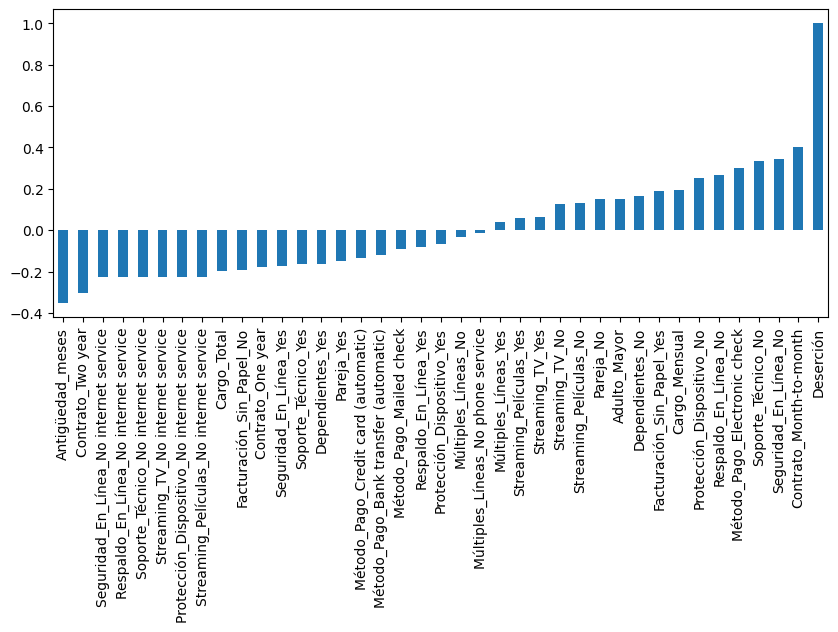

In [85]:
plt.figure(figsize=(10,4))
Data_Kaggle_Int.corr()["Deserción"].sort_values(ascending=True).plot(kind="bar")
plt.show()

## Definición de Variable Dependiente y de Variables Independientes

In [ ]:
Campos_Sin_Aporte = {"Género","Servicio_Teléfono"}
Data_Kaggle = Data_Kaggle.drop(columns=Campos_Sin_Aporte, axis=1)

In [75]:
# Variable Dependiente
y = Data_Kaggle['Deserción']
# Variables Independientes en el peor de los casos, Considero que estas Variables son las que llevan al extremo el modelo para ser mas exacto porque sería el _pero de los casos
x = columnas = [col for col in Data_Kaggle.columns if "_peor" in col]

In [76]:
Columnas_Segmentos = Data_Kaggle.select_dtypes(include=object).columns #Obtenemos columnas de segmentos

#Recorremos los segmentos y llamamos la función de creación de graficas
for columna in Columnas_Segmentos:
    plt_Categoria(columna)

### Analisis exploratorio de los datos

In [77]:
# Obtenemos X y Y de las graficas 
Data_Kaggle_x = Data_Kaggle.drop(columns=["Deserción"]) 
Data_Kaggle_y = Data_Kaggle["Deserción"] 

#Unimos X y Y de nuevo para validaciones 
Data_Kaggle_Int = pd.get_dummies(Data_Kaggle_x).astype(int).copy() 
Data_Kaggle_Int["Deserción"] = Data_Kaggle_y 

# Cambiamos el campo Deserción a Numeros No = 0 y Si = 1 
#Data_Kaggle_Int["Deserción"] = Data_Kaggle_Int["Deserción"].str.strip().replace().map({"Si": 1, "No": 0}).fillna(0).astype(int)

corr = Data_Kaggle_Int.corr(numeric_only=True)["Deserción"].sort_values(ascending=True)

# Convertimos a DataFrame
df_corr = corr.reset_index()
df_corr.columns = ["Variable", "Correlacion"]

# Creamos columna Color
df_corr["Color"] = df_corr["Correlacion"].apply(lambda x: "Negativo" if x < 0 else "Positivo")

fig = px.bar(
    df_corr,
    x="Correlacion",
    y="Variable",
    orientation="h",
    color="Color",
    color_discrete_map={"Negativo": "darkred", "Positivo": "darkblue"},
    labels={"Correlacion":"Correlación con Deserción", "Variable":"Variables"},
    title="Correlación de variables con Deserción"
)

fig.update_layout(
    width=890,
    height=800,
    yaxis=dict(showticklabels=False)
)

# Etiquetas centradas en x=0
for var in df_corr["Variable"]:
    fig.add_annotation(
        x=0,
        y=var,
        text=var,
        showarrow=False,
        font=dict(color="white", size=12),
        xanchor="center"
    )

Estilos(fig)
fig.show()

<Figure size 1000x600 with 0 Axes>

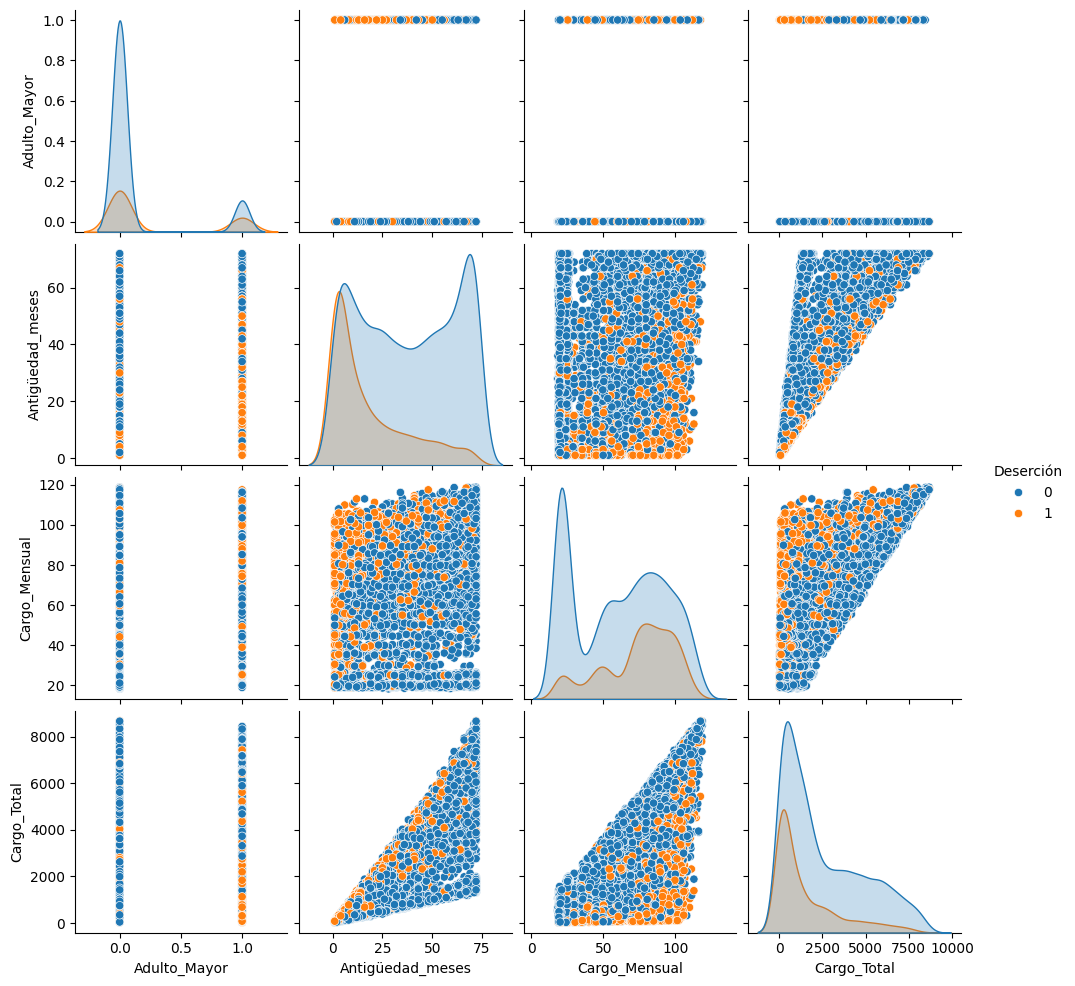

In [78]:
# Grafico de correlación
plt.figure(figsize=(10,6))
sns.pairplot(data=Data_Kaggle, hue="Deserción")
plt.show()

### Datos Escalares

In [79]:
#Datos de escalamiento
Escalar = MinMaxScaler()
Data_Kaggle_Escalar = Escalar.fit_transform(Data_Kaggle_Int)

#DataFrame Datos escalamiento
Data_Kaggle_Escalar_DF = pd.DataFrame(Data_Kaggle_Escalar)

#Pasamos nombre de los campos al DF Escalar
Data_Kaggle_Escalar_DF.columns = Data_Kaggle_Int.columns
#Data_Kaggle_Escalar_DF


### Entrenamiento del modelo de regresión logistica

In [80]:
x = Data_Kaggle_Escalar_DF.drop("Deserción", axis=1)
y = Data_Kaggle_Escalar_DF["Deserción"].values

# Obtenemos Variables de entrenamiento
x_train, x_test, y_train, y_test = train_test_split(
    x, 
    y, 
    test_size=0.3, 
    random_state=42,
    stratify=y # Se Agrega para mejorar el modelo, estratifica los datos a partir de Diagnóstico
)

Modelo = LogisticRegression()
Modelo.fit(x_train, y_train)
Prediccion = Modelo.predict(x_test)

# Obtenemos el porentaje de exactitud de precisión del modelo
Exactitud = accuracy_score(y_test ,Prediccion)
print(f"Porcentaje de precisión del modelo: {Exactitud*100:.2f}%")

Porcentaje de precisión del modelo: 80.47%


### Evaluación y Caracteristicas del modelo

In [81]:
#Evaluación del modelo
Modelo.predict_proba(x_test)

#Caracteristicas
Modelo.feature_names_in_

pesos = pd.Series(Modelo.coef_[0], index=x.columns.values)
pesos_DF = pd.DataFrame({
    "Variable": x.columns.values,
    "Coeficiente": Modelo.coef_[0]
}).sort_values(by="Coeficiente", ascending=False)

In [82]:
pesos_DF["Color"] = pesos_DF["Coeficiente"].apply(lambda x: "Negativo" if x < 0 else "Positivo")

fig = px.bar(
    pesos_DF,
    x="Variable",
    y="Coeficiente",
    color="Color",
    color_discrete_map={"Negativo": "darkred", "Positivo": "darkblue"},
    labels={"x":"Variables", "y":"Coeficiente"},
    title="Coeficientes del Modelo (Logistic Regression)"
)

fig.update_layout(width=890, height=900)

Estilos(fig)
fig.show()

### Matriz de confusión

In [83]:
Matriz_Confucion_II = confusion_matrix(y_test, Prediccion)

# Mostrar valores en consola
print(f"Verdaderos Negativos (VN): {Matriz_Confucion_II[0][0]} Personas que No Desertaron y el modelo dijo No Desertaron.")
print(f"Verdadero Positivo (VP): {Matriz_Confucion_II[1][1]} Personas que SÍ Desertaron y el modelo dijo No Desertaron.")
print(f"Falso Positivos (FP): {Matriz_Confucion_II[0][1]} Personas que No Desertaron, pero el modelo dijo que SÍ Desertaron.")
print(f"Falso Negativo (FN): {Matriz_Confucion_II[1][0]} Personas que SÍ Desertaron, pero el modelo dijo que No Desertaron.")

# Heatmap con Plotly
fig = px.imshow(
    Matriz_Confucion_II,
    text_auto=True,
    color_continuous_scale="Blues",
    labels=dict(x="Predicciones", y="Verdaderos", color="Cantidad"),
    x=["Sin Deserción (0)", "Con Deserción (1)"],
    y=["Sin Deserción (0)", "Con Deserción (1)"]
)

fig.update_layout(
    title="Matriz de Confusión",
    width=600,
    height=500
)

Estilos(fig)

fig.show()

Verdaderos Negativos (VN): 1382 Personas que No Desertaron y el modelo dijo No Desertaron.
Verdadero Positivo (VP): 316 Personas que SÍ Desertaron y el modelo dijo No Desertaron.
Falso Positivos (FP): 167 Personas que No Desertaron, pero el modelo dijo que SÍ Desertaron.
Falso Negativo (FN): 245 Personas que SÍ Desertaron, pero el modelo dijo que No Desertaron.
